# Bank Marketing Campaign — Exploratory Analysis

A retail bank ran an outbound telemarketing campaign selling term deposits.
This notebook walks through the exploratory analysis behind the project:
data quality, who converts, how contact frequency affects outcomes, and what
the bank should change in the next campaign.

The reproducible pipeline lives in `src/` and `sql/`; this notebook is the
exploration that motivated those queries.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 25)

raw = pd.read_csv("../data/raw/bank-additional-full.csv", sep=";")
print(raw.shape)
raw.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Structure and data quality

Before any analysis: how clean is this extract? Three things stand out in this
dataset and each needs an explicit decision.

In [2]:
# No literal NaNs anywhere — but that doesn't mean no missing data.
print("Literal NaNs:", int(raw.isna().sum().sum()))
print("Exact duplicate rows:", int(raw.duplicated().sum()))

# Missingness hides inside 'unknown' category levels instead.
unknown_share = (
    raw.select_dtypes("object")
    .apply(lambda s: (s == "unknown").mean() * 100)
    .round(1)
    .sort_values(ascending=False)
)
unknown_share[unknown_share > 0]

Literal NaNs: 0
Exact duplicate rows: 12


/tmp/ipykernel_6250/2408771615.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  raw.select_dtypes("object")


default      20.9
education     4.2
housing       2.4
loan          2.4
job           0.8
marital       0.2
dtype: float64

**Decisions taken:**

1. **12 duplicate rows** → dropped. With no client ID in the extract, identical
   rows across 21 columns are almost certainly double-loads, not coincidence.
2. **`unknown` levels** (notably `default` at ~21%) → kept as their own
   category and reported, not imputed. For campaign reporting, "we don't know"
   is itself information.
3. **`pdays = 999`** is a sentinel for "never contacted before" — left as-is it
   would wreck any average. Replaced with `NULL` + a `previously_contacted`
   flag.
4. **`duration`** (call length) is only known *after* the call ends, so it
   can't drive targeting. It stays out of every recommendation in this
   project.

In [3]:
df = raw.drop_duplicates().copy()
df["converted"] = (df["y"] == "yes").astype(int)
df["previously_contacted"] = (df["pdays"] != 999).astype(int)
df["pdays"] = df["pdays"].where(df["pdays"] != 999)

overall = df["converted"].mean() * 100
print(f"{len(df):,} unique contacts | overall conversion: {overall:.1f}%")

41,176 unique contacts | overall conversion: 11.3%


An 11.3% baseline means roughly 1 sale per 9 calls. The question for the
rest of the analysis: which calls were worth making?

## 2. Customer history — the strongest signal

The bank knows how each client responded to *previous* campaigns
(`poutcome`). How much does that history matter?

In [4]:
history = (
    df.groupby("poutcome")["converted"]
    .agg(contacts="size", conversion_rate="mean")
    .assign(conversion_rate=lambda x: (x["conversion_rate"] * 100).round(1))
    .sort_values("conversion_rate", ascending=False)
)
history

,contacts,conversion_rate
poutcome,,
success,1373,65.1
failure,4252,14.2
nonexistent,35551,8.8


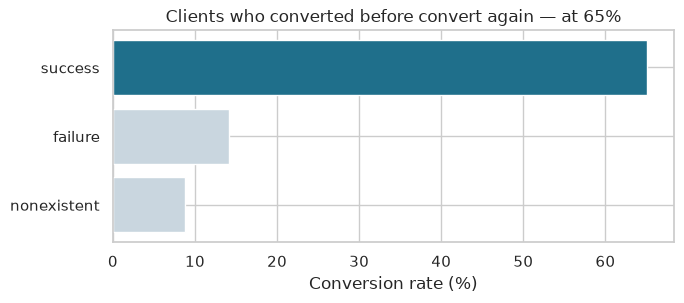

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
order = history.index.tolist()
colors = ["#1f6f8b" if p == "success" else "#c9d6df" for p in order]
ax.barh(order, history["conversion_rate"], color=colors)
ax.set_xlabel("Conversion rate (%)")
ax.set_title("Clients who converted before convert again — at 65%")
ax.invert_yaxis()
plt.tight_layout()

Clients who said *yes* in a previous campaign convert at **~65%** — almost
**6x the campaign average**. Even a previous *failure* (14.2%) beats a cold
contact (8.8%): any prior relationship warms the lead.

Recency amplifies this. Among prior successes re-contacted within a week,
conversion reaches **66%**:

In [6]:
recency = pd.cut(
    df["pdays"],
    bins=[0, 7, 30, 1000],
    labels=["within 1 week", "1-4 weeks", "over a month"],
)
(
    df[df["previously_contacted"] == 1]
    .groupby(["poutcome", recency], observed=True)["converted"]
    .agg(contacts="size", conversion_rate="mean")
    .assign(conversion_rate=lambda x: (x["conversion_rate"] * 100).round(1))
)

contacts  conversion_rate
poutcome pdays                                   
failure  within 1 week        50             50.0
         1-4 weeks            92             52.2
success  within 1 week      1112             66.5
         1-4 weeks           246             58.9

Yet only **3.3%** of this campaign's contacts had a prior success — the
highest-value list was barely used.

## 3. Demographic segments

Job is the most discriminating demographic. Age tells the same story from a
different angle.

In [7]:
seg = (
    df.groupby("job")["converted"]
    .agg(contacts="size", conversion_rate="mean")
    .assign(conversion_rate=lambda x: (x["conversion_rate"] * 100).round(1))
    .sort_values("conversion_rate", ascending=False)
)
seg

,contacts,conversion_rate
job,,
student,875,31.4
retired,1718,25.3
unemployed,1014,14.2
admin.,10419,13.0
unknown,330,11.2
management,2924,11.2
technician,6739,10.8
self-employed,1421,10.5
housemaid,1060,10.0


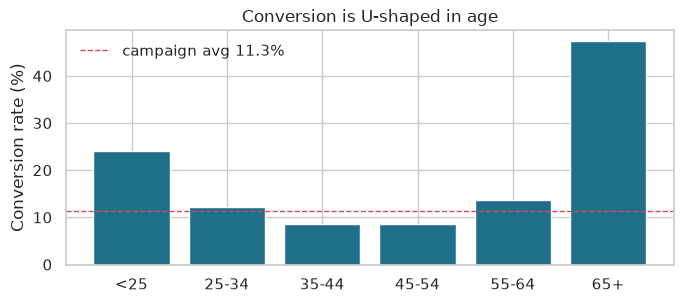

In [8]:
age_band = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 200],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False,
)
by_age = (
    df.groupby(age_band, observed=True)["converted"]
    .agg(contacts="size", conversion_rate="mean")
    .assign(conversion_rate=lambda x: (x["conversion_rate"] * 100).round(1))
)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(by_age.index.astype(str), by_age["conversion_rate"], color="#1f6f8b")
ax.axhline(overall, color="#d1495b", ls="--", lw=1,
           label=f"campaign avg {overall:.1f}%")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion is U-shaped in age")
ax.legend(frameon=False)
plt.tight_layout()

Students (**31%**) and retirees (**25%**) convert at 2–3x the average, and
the age curve is U-shaped: under-25s and over-65s respond best, while the
35–54 core — the bulk of the call list — sits *below* average. The campaign
spent most of its effort on its weakest audience.

## 4. Contact frequency — does persistence pay?

`campaign` counts how many times each client was called during this
campaign.

In [9]:
freq = (
    df.groupby(df["campaign"].clip(upper=8))["converted"]
    .agg(clients="size", conversion_rate="mean")
    .assign(conversion_rate=lambda x: (x["conversion_rate"] * 100).round(1))
)
freq.index = [str(i) if i < 8 else "8+" for i in freq.index]
freq

,clients,conversion_rate
1,17634,13.0
2,10568,11.5
3,5340,10.7
4,2650,9.4
5,1599,7.5
6,979,7.7
7,629,6.0
8+,1777,4.1


Conversion falls **monotonically** with every additional call: **13.0%** on
the first contact down to **6.0%** by the seventh and ~4% beyond. Persistence
doesn't recover non-responders — it burns agent time and goodwill.

A caveat worth stating in an interview: this is observational, not causal —
clients who needed many calls are plausibly harder sells to begin with. But
the *operational* conclusion holds either way: effort beyond ~3 contacts
produced almost no incremental yield (see `sql/03_contact_frequency.sql` for
the effort-vs-yield split).

## 5. Channel and timing

In [10]:
channel = (
    df.groupby("contact")["converted"]
    .agg(contacts="size", conversion_rate="mean")
    .assign(conversion_rate=lambda x: (x["conversion_rate"] * 100).round(1))
)
channel

,contacts,conversion_rate
contact,,
cellular,26135,14.7
telephone,15041,5.2


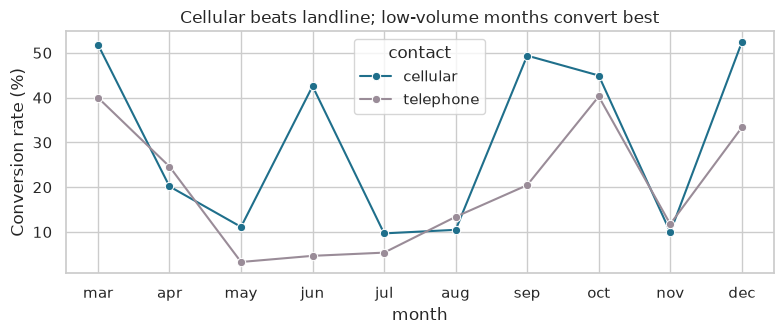

In [11]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
by_month = (
    df.assign(month=pd.Categorical(df["month"], month_order, ordered=True))
    .groupby(["month", "contact"], observed=True)["converted"]
    .agg(contacts="size", conversion_rate="mean")
    .reset_index()
)
by_month["conversion_rate"] *= 100

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.lineplot(data=by_month, x="month", y="conversion_rate", hue="contact",
             marker="o", palette=["#1f6f8b", "#9a8c98"], ax=ax)
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Cellular beats landline; low-volume months convert best")
plt.tight_layout()

Cellular contacts convert at **14.7%** vs **5.2%** on landlines — a near 3x
gap. The monthly view adds nuance: the spectacular rates in March, September,
October and December coincide with *tiny* call volumes, while May — the
biggest month by far — converted worst. That pattern points to list
saturation: when the bank blasted its full list, quality collapsed.

## 6. Takeaways

| # | Finding | Action |
|---|---------|--------|
| 1 | Prior converters: ~65% conversion, only 3.3% of contacts | Build the next list around customer history first |
| 2 | Conversion decays 13% → 6% across repeat calls | Cap attempts at ~3 and recycle effort into fresh leads |
| 3 | Students & retirees convert at 2–3x average | Weight targeting toward under-25 / over-65 segments |
| 4 | Cellular ≈ 3x landline conversion | Prioritise mobile numbers in dialer queues |

The polished versions of these cuts live in `sql/` (queries),
`outputs/figures/` (report charts) and `tableau/` (dashboard extracts).